# Three-Layer MLP Benchmark
Cross-sectional equity return prediction in the Emerging Markets universe. The MLP receives the full set of rank-normalised JKP characteristics with median imputation for missing values, processes them through three hidden layers of width `d_model` with ELU activations and dropout, and projects to a scalar return prediction.

Two portfolio constructions are a long-short quintile portfolio for direct comparison with the dissertation headline Sharpe, and a long-only top-quintile portfolio for comparison with the MSCI EM Gross long-only benchmark. The Optuna objective optimises validation long-short Sharpe. The long-only validation Sharpe is tracked as a trial diagnostic.

In [1]:
import json
import time
import pickle
import warnings
from datetime import datetime
from pathlib import Path

import pyarrow as pa
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
import torch.nn as nn
import optuna
from safetensors.torch import save_file as safetensors_save
from scipy.stats import spearmanr
import matplotlib
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

In [2]:
cuda_available = torch.cuda.is_available()
device = torch.device('cuda' if cuda_available else 'cpu')
cuda_device_name = torch.cuda.get_device_name(0) if cuda_available else None
print(f'cuda available: {cuda_available}')
print(f'device: {device}')
if cuda_available:
    print(f'device name:{cuda_device_name}')

cuda available: True
device: cuda
device name:NVIDIA GeForce RTX 2080 Super with Max-Q Design


In [3]:
data_path = Path('../data/Global Factor_EM.parquet')
results_dir = Path('../results/benchmark/mlp_benchmark')
results_dir.mkdir(parents = True, exist_ok = True)

train_end = pd.Timestamp('2015-12-31')
val_end = pd.Timestamp('2020-12-31')

ret_col = 'ret_exc_lead1m'
rebalance_freq = 3
tc_bps = 25
min_stocks = 30
ret_clip_low = -1.0
ret_clip_high =  1.0

target_vol = 0.10
vol_lookback = 12
max_leverage_ls = 3.0
max_leverage_lo = 3.0

n_epochs_train = 100
patience = 10
grad_clip_norm = 1.0

n_trials = 30
optuna_seed = 24
torch_seed = 24

run_timestamp = datetime.utcnow().isoformat(timespec = 'seconds')
print(f'run timestamp:{run_timestamp}')

run timestamp:2026-06-25T17:15:47


In [4]:
schema = pq.read_schema(data_path)
non_feature = {
    'id', 'gvkey', 'isin', 'cusip', 'permno', 'permco',
    'eom', 'excntry', 'sic', 'naics', 'source_crsp', ret_col,
}

feature_cols = [
    c for c in schema.names
    if c not in non_feature
    and pa.types.is_floating(schema.field(c).type)
]

print(f'feature columns selected, {len(feature_cols)}')

needed = list(dict.fromkeys(
    [c for c in ['id', 'eom', 'excntry', ret_col] + feature_cols if c in schema.names]
))
df = pd.read_parquet(data_path, columns = needed)
df['eom'] = pd.to_datetime(df['eom'])

for col in feature_cols:
    if col in df.columns and df[col].dtype == np.float64:
        df[col] = df[col].astype(np.float32)
df[ret_col] = df[ret_col].clip(lower = ret_clip_low, upper = ret_clip_high)

print(f'loaded: {df.shape[0]:,} rows, {len(feature_cols)} characteristic columns')
print(f'date range: {df["eom"].min().date()} to {df["eom"].max().date()}')

feature columns selected, 421
loaded: 4,386,856 rows, 421 characteristic columns
date range: 1995-01-31 to 2025-12-31


In [5]:
# median imputation: zero in rank-normalised space is the cross-sectional median
sorted_eoms = sorted(df['eom'].unique())
all_months = {}
n_feat = len(feature_cols)

for eom in sorted_eoms:
    month = df[df['eom'] == eom].copy()
    month = month[month[ret_col].notna()]
    if len(month) < min_stocks:
        continue
    ids = month['id'].values
    r   = month[ret_col].values.astype(np.float64)
    x = np.zeros((len(month), n_feat), dtype = np.float32)
    for j, col in enumerate(feature_cols):
        if col not in month.columns:
            continue
        vals = month[col].values.astype(np.float64)
        valid = np.isfinite(vals)
        if valid.sum() > 1:
            x[valid, j] = (pd.Series(vals[valid]).rank(pct = True).values - 0.5).astype(np.float32)
    all_months[eom] = {'ids': ids, 'r': r, 'x': x}

sorted_dates = sorted(all_months.keys())
print(f'processed: {len(sorted_dates)} months')
print(f'avg firms/month: {np.mean([len(m["ids"]) for m in all_months.values()]):.0f}')

processed: 372 months
avg firms/month: 11648


In [6]:
train_dates = [d for d in sorted_dates if d <= train_end]
val_dates = [d for d in sorted_dates if train_end < d <= val_end]
test_dates = [d for d in sorted_dates if d > val_end]

x_train = np.vstack([all_months[d]['x'] for d in train_dates])
y_train = np.concatenate([all_months[d]['r'] for d in train_dates]).astype(np.float32)
print(f'train months: {len(train_dates)}, val months: {len(val_dates)}, test months: {len(test_dates)}')
print(f'x_train: {x_train.shape}')

train months: 252, val months: 60, test months: 60
x_train: (2175929, 421)


In [7]:
class MLP(nn.Module):
    def __init__(self, n_features, d_model, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, d_model), nn.ELU(), nn.Dropout(dropout),
            nn.Linear(d_model, d_model), nn.ELU(), nn.Dropout(dropout),
            nn.Linear(d_model, d_model), nn.ELU(), nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


class MLPPredictor:
    def __init__(self, model, device):
        self.model  = model
        self.device = device

    def predict(self, x):
        self.model.eval()
        with torch.no_grad():
            x_t = torch.from_numpy(x).float().to(self.device)
            return self.model(x_t).cpu().numpy()

In [8]:
def portfolio_metrics(rets):
    rets = np.array(rets, dtype = np.float64)
    if len(rets) == 0:
        return {}
    tw = float((1.0 + rets).prod())
    ann_ret = -1.0 if tw <= 0 else float(tw ** (12.0 / len(rets)) - 1.0)
    ann_vol = float(rets.std() * np.sqrt(12.0))
    sharpe = ann_ret / max(ann_vol, 1e-8)
    se = float(np.sqrt((1.0 + 0.5 * sharpe ** 2) / len(rets)))
    cw = np.cumprod(1.0 + rets)
    pk = np.maximum.accumulate(cw)
    max_dd = float(((pk - cw) / pk).max()) if len(cw) > 0 else 0.0
    return {
        'ann_ret': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
        'se_sharpe': se, 'max_dd': max_dd, 'n_obs': len(rets),
    }


def apply_vol_target(monthly_rets, rebalance_indices, target_vol, vol_lookback, max_leverage):
    scaled = np.array(monthly_rets, dtype = np.float64)
    n = len(monthly_rets)
    n_rb = len(rebalance_indices)
    period_rets = []
    for i in range(1, n_rb):
        window = np.array(monthly_rets[rebalance_indices[i - 1]:rebalance_indices[i]])
        period_rets.append(float(np.prod(1.0 + window) - 1.0))
    for i in range(n_rb):
        if i < vol_lookback:
            continue
        trailing = np.array(period_rets[max(0, i - vol_lookback):i])
        if len(trailing) < 2:
            continue
        sigma_ann = float(trailing.std() * np.sqrt(12.0 / rebalance_freq))
        lev = float(np.clip(target_vol / max(sigma_ann, 1e-8), 1.0 / max_leverage, max_leverage))
        next_rb = rebalance_indices[i + 1] if i + 1 < n_rb else n
        scaled[rebalance_indices[i]:next_rb] = (
            np.array(monthly_rets[rebalance_indices[i]:next_rb]) * lev
        )
    return scaled


def predict_test(predictor, month_dates):
    rows = []
    for eom in month_dates:
        if eom not in all_months:
            continue
        m = all_months[eom]
        pred = predictor.predict(m['x'])
        for k in range(len(m['ids'])):
            rows.append({
                'eom': eom, 'id': m['ids'][k],
                'prediction': float(pred[k]), 'realised_return': float(m['r'][k]),
            })
    return pd.DataFrame(rows)


def rank_correlation_oos(predictor, month_dates):
    corrs = []
    for eom in month_dates:
        if eom not in all_months:
            continue
        m = all_months[eom]
        pred = predictor.predict(m['x'])
        valid = np.isfinite(pred) & np.isfinite(m['r'])
        if valid.sum() < 10:
            continue
        c, _ = spearmanr(pred[valid], m['r'][valid])
        if not np.isnan(c):
            corrs.append(float(c))
    return float(np.mean(corrs)) if corrs else 0.0


def run_quintile_simulation(predictor, month_dates):
    """
    Quintile simulation producing both long-short and long-only portfolios.
    Long-short:top quintile equal-weighted long, bottom quintile equal-weighted short.
    Long-only:top quintile equal-weighted, no short leg.
    Turnover is computed per leg using firm identifiers.
    """
    rset = set(month_dates[::rebalance_freq])

    ls_rets, ls_dates, ls_rb_indices = [], [], []
    lo_rets, lo_dates, lo_rb_indices = [], [], []

    li_ids = []
    si_ids = []
    prev_li = set()
    prev_si = set()

    ls_holdings, lo_holdings = [], []
    rb_counter = -1

    for eom in month_dates:
        if eom not in all_months:
            continue
        m = all_months[eom]
        ids = m['ids']
        r = m['r']
        x = m['x']

        ls_tcv = 0.0
        lo_tcv = 0.0

        if eom in rset:
            ls_rb_indices.append(len(ls_rets))
            lo_rb_indices.append(len(lo_rets))
            rb_counter += 1

            pred = predictor.predict(x)
            valid = np.isfinite(pred)
            if valid.sum() < 10:
                continue

            vi = ids[valid]
            vp = pred[valid]
            nq = max(1, int(len(vi) * 0.20))
            so = np.argsort(vp)
            li_ids = vi[so[::-1][:nq]].tolist()
            si_ids = vi[so[:nq]].tolist()
            li_set = set(li_ids)
            si_set = set(si_ids)

            ls_to = (
                len(li_set - prev_li) + len(prev_li - li_set)
                + len(si_set - prev_si) + len(prev_si - si_set)
            ) / max(nq, 1)
            ls_tcv = ls_to * tc_bps / 10000.0

            lo_to = (
                len(li_set - prev_li) + len(prev_li - li_set)
            ) / max(nq, 1)
            lo_tcv = lo_to * tc_bps / 10000.0

            prev_li = li_set
            prev_si = si_set

            wt_long = 1.0 / max(len(li_ids), 1)
            wt_short = -1.0 / max(len(si_ids), 1)

            for fid in li_ids:
                ls_holdings.append({
                    'rebalance_index': rb_counter, 'eom': eom, 'leg': 'long',
                    'id': fid, 'weight': wt_long,
                })
                lo_holdings.append({
                    'rebalance_index': rb_counter, 'eom': eom, 'leg': 'long',
                    'id': fid, 'weight': wt_long,
                })
            for fid in si_ids:
                ls_holdings.append({
                    'rebalance_index': rb_counter, 'eom': eom, 'leg': 'short',
                    'id': fid, 'weight': wt_short,
                })

        if not li_ids:
            continue

        li_mask = np.isin(ids, li_ids)
        si_mask = np.isin(ids, si_ids)
        lr = r[li_mask]
        sr = r[si_mask]
        lr_mean = float(lr.mean()) if len(lr) > 0 else 0.0
        sr_mean = float(sr.mean()) if len(sr) > 0 else 0.0

        ls_rets.append(lr_mean - sr_mean - ls_tcv)
        ls_dates.append(eom)

        lo_rets.append(lr_mean - lo_tcv)
        lo_dates.append(eom)

    return {
        'long_short': {
            'returns': np.array(ls_rets),
            'rb_indices': ls_rb_indices,
            'holdings_df': pd.DataFrame(ls_holdings),
            'returns_df': pd.DataFrame({'eom': ls_dates, 'return_raw': ls_rets}),
        },
        'long_only': {
            'returns': np.array(lo_rets),
            'rb_indices': lo_rb_indices,
            'holdings_df': pd.DataFrame(lo_holdings),
            'returns_df':  pd.DataFrame({'eom': lo_dates, 'return_raw': lo_rets}),
        },
    }

In [9]:
def train_mlp(params, x_train_pool, y_train_pool, val_dates_local,
              n_epochs, patience, device, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if device.type == 'cuda':
        torch.cuda.manual_seed_all(seed)

    model = MLP(
        n_features = x_train_pool.shape[1],
        d_model = params['d_model'],
        dropout = params['dropout'],
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr = params['learning_rate'],
        weight_decay = params['weight_decay'],
    )
    criterion = nn.MSELoss()

    x_train_t = torch.from_numpy(x_train_pool).float().to(device)
    y_train_t = torch.from_numpy(y_train_pool).float().to(device)
    n_train = len(x_train_t)
    batch_size = params['batch_size']

    predictor = MLPPredictor(model, device)

    best_rc = -np.inf
    best_state = None
    best_epoch = 0
    patience_ctr = 0
    train_losses, val_rank_corr = [], []

    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(n_train, device = device)
        epoch_loss = 0.0
        n_batches  = 0
        for i in range(0, n_train, batch_size):
            idx = perm[i:i + batch_size]
            x_batch = x_train_t[idx]
            y_batch = y_train_t[idx]
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = grad_clip_norm)
            optimizer.step()
            epoch_loss += float(loss.item())
            n_batches  += 1

        avg_loss = epoch_loss / max(n_batches, 1)
        val_rc = rank_correlation_oos(predictor, val_dates_local)
        train_losses.append(avg_loss)
        val_rank_corr.append(val_rc)

        if val_rc > best_rc:
            best_rc = val_rc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, {
        'train_losses': train_losses, 'val_rank_corr': val_rank_corr,
        'best_epoch': best_epoch, 'best_val_rc': float(best_rc),
        'n_epochs_run': len(train_losses),
    }

### Hyperparameter search

In [10]:
# objective: validation long-short sharpe at best rank-correlation epoch.
# long-only sharpe is tracked as a trial diagnostic.

def mlp_objective(trial):
    params = {
        'd_model': trial.suggest_categorical('d_model', [32, 64, 128, 256]),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log = True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-2, log = True),
        'batch_size': trial.suggest_categorical('batch_size', [512, 1024, 2048]),
    }
    model, log = train_mlp(
        params = params, x_train_pool = x_train, y_train_pool = y_train,
        val_dates_local = val_dates, n_epochs = n_epochs_train,
        patience = patience, device = device, seed = torch_seed,
    )
    predictor = MLPPredictor(model, device)

    sim = run_quintile_simulation(predictor, val_dates)
    ls, lo = sim['long_short'], sim['long_only']
    if len(ls['returns']) == 0:
        return -999.0
    ls_scaled = apply_vol_target(ls['returns'], ls['rb_indices'], target_vol, vol_lookback, max_leverage_ls)
    lo_scaled = apply_vol_target(lo['returns'], lo['rb_indices'], target_vol, vol_lookback, max_leverage_lo)
    ls_sharpe = portfolio_metrics(ls_scaled).get('sharpe', -999.0)
    lo_sharpe = portfolio_metrics(lo_scaled).get('sharpe', -999.0)

    trial.set_user_attr('best_epoch', log['best_epoch'])
    trial.set_user_attr('n_epochs_run', log['n_epochs_run'])
    trial.set_user_attr('best_val_rc', log['best_val_rc'])
    trial.set_user_attr('val_sharpe_long_only', float(lo_sharpe))
    return ls_sharpe


mlp_study = optuna.create_study(
    direction = 'maximize',
    sampler = optuna.samplers.TPESampler(seed = optuna_seed),
    study_name = f'mlp_em_{run_timestamp}',
)
t0 = time.time()
mlp_study.optimize(mlp_objective, n_trials = n_trials, show_progress_bar = True)
mlp_hpo_time = time.time() - t0
mlp_best = mlp_study.best_params
print(f'MLP best val ls sharpe: {mlp_study.best_value:.4f}')
print(f'MLP best params:{mlp_best}')
print(f'MLP hpo time:{mlp_hpo_time:.1f} s ({mlp_hpo_time / 60:.2f} min)')

  0%|          | 0/30 [00:00<?, ?it/s]

MLP best val ls sharpe: 3.9607
MLP best params:{'d_model': 128, 'dropout': 0.34033148208546443, 'learning_rate': 0.00035579945609317095, 'weight_decay': 0.0002605669233332669, 'batch_size': 512}
MLP hpo time:5311.3 s (88.52 min)


In [11]:
mlp_trials_df = mlp_study.trials_dataframe()
mlp_trials_df.to_csv(results_dir / 'mlp_optuna_trials.csv', index = False)
with open(results_dir / 'mlp_optuna_study.pkl', 'wb') as fh:
    pickle.dump(mlp_study, fh)
print(f'mlp trials saved: {len(mlp_trials_df)} rows')

mlp trials saved: 30 rows


In [12]:
t0 = time.time()
mlp_model, mlp_log = train_mlp(
    params = mlp_best, x_train_pool = x_train, y_train_pool = y_train,
    val_dates_local = val_dates, n_epochs = n_epochs_train,
    patience = patience, device = device, seed = torch_seed,
)
mlp_train_time = time.time() - t0
mlp_predictor = MLPPredictor(mlp_model, device)
n_params = sum(p.numel() for p in mlp_model.parameters())

print(f'MLP final model: trained in {mlp_train_time:.1f} s')
print(f'best epoch: {mlp_log["best_epoch"]} of {mlp_log["n_epochs_run"]}')
print(f'best val rc: {mlp_log["best_val_rc"]:.4f}')
print(f'parameter count: {n_params:,}')

safetensors_save(mlp_model.state_dict(), str(results_dir / 'mlp_weights.safetensors'))
mlp_train_log = {
    'train_losses': mlp_log['train_losses'], 'val_rank_corr': mlp_log['val_rank_corr'],
    'best_epoch': mlp_log['best_epoch'], 'best_val_rc': mlp_log['best_val_rc'],
    'n_epochs_run': mlp_log['n_epochs_run'],
    'training_time_seconds': float(mlp_train_time),
    'parameter_count': int(n_params),
}
with open(results_dir / 'em_mlp_train_log.json', 'w') as fh:
    json.dump(mlp_train_log, fh, indent = 2, default = float)

MLP final model: trained in 240.6 s
best epoch: 4 of 15
best val rc: 0.0873
parameter count: 87,169


In [13]:
mlp_rc_val = rank_correlation_oos(mlp_predictor, val_dates)
mlp_rc_test = rank_correlation_oos(mlp_predictor, test_dates)
print(f'MLP rank corr: val = {mlp_rc_val:.4f}, test = {mlp_rc_test:.4f}')

MLP rank corr: val = 0.0873, test = 0.0961


In [14]:
# test set evaluation: both long-short and long-only

sim = run_quintile_simulation(mlp_predictor, test_dates)
ls, lo = sim['long_short'], sim['long_only']

ls_scaled = apply_vol_target(ls['returns'], ls['rb_indices'], target_vol, vol_lookback, max_leverage_ls)
lo_scaled = apply_vol_target(lo['returns'], lo['rb_indices'], target_vol, vol_lookback, max_leverage_lo)
ls['returns_df']['return_scaled'] = ls_scaled
lo['returns_df']['return_scaled'] = lo_scaled

mlp_metrics = {
    'long_short_raw': portfolio_metrics(ls['returns']),
    'long_short_scaled': portfolio_metrics(ls_scaled),
    'long_only_raw': portfolio_metrics(lo['returns']),
    'long_only_scaled': portfolio_metrics(lo_scaled),
}

ls['returns_df'].to_csv(results_dir / 'mlp_returns_long_short.csv', index = False)
lo['returns_df'].to_csv(results_dir / 'mlp_returns_long_only.csv', index = False)
ls['holdings_df'].to_csv(results_dir / 'mlp_holdings_long_short.csv', index = False)
lo['holdings_df'].to_csv(results_dir / 'mlp_holdings_long_only.csv', index = False)
predict_test(mlp_predictor, test_dates).to_csv(
    results_dir / 'em_mlp_test_predictions.csv', index = False,
)

mls = mlp_metrics['long_short_scaled']
mlo = mlp_metrics['long_only_scaled']
print(f'MLP long-short (vol): sharpe = {mls["sharpe"]:.4f}, ann_ret = {mls["ann_ret"] * 100:.2f}%, ann_vol = {mls["ann_vol"] * 100:.2f}%')
print(f'MLP long-only  (vol): sharpe = {mlo["sharpe"]:.4f}, ann_ret = {mlo["ann_ret"] * 100:.2f}%, ann_vol = {mlo["ann_vol"] * 100:.2f}%')

MLP long-short (vol): sharpe = 3.6953, ann_ret = 38.52%, ann_vol = 10.43%
MLP long-only  (vol): sharpe = 2.6113, ann_ret = 30.79%, ann_vol = 11.79%


In [15]:
summary = {
    'run_timestamp_utc': run_timestamp,
    'n_features': len(feature_cols), 'feature_cols': feature_cols,
    'architecture': {
        'name': 'three-layer MLP', 'n_hidden_layers': 3,
        'hidden_width': mlp_best['d_model'], 'activation': 'ELU',
        'dropout': mlp_best['dropout'],
        'imputation': 'median (zero in rank-normalised space)',
        'parameter_count': int(n_params),
    },
    'split': {
        'train':{'start': str(train_dates[0].date()), 'end': str(train_dates[-1].date()),
                  'n_months': len(train_dates), 'n_obs': int(x_train.shape[0])},
        'val':{'start': str(val_dates[0].date()), 'end': str(val_dates[-1].date()),
                  'n_months': len(val_dates)},
        'test':{'start': str(test_dates[0].date()), 'end': str(test_dates[-1].date()),
                  'n_months': len(test_dates)},
    },
    'config': {
        'rebalance_freq': rebalance_freq, 'tc_bps': tc_bps, 'min_stocks': min_stocks,
        'ret_clip': [ret_clip_low, ret_clip_high],
        'target_vol': target_vol, 'vol_lookback': vol_lookback,
        'max_leverage_ls': max_leverage_ls, 'max_leverage_lo': max_leverage_lo,
        'n_epochs_train': n_epochs_train, 'patience': patience,
        'grad_clip_norm': grad_clip_norm, 'optuna_seed': optuna_seed,
        'torch_seed': torch_seed, 'n_trials': n_trials,
    },
    'mlp': {
        'best_params': mlp_best,
        'best_val_long_short_sharpe': float(mlp_study.best_value),
        'best_trial_number': int(mlp_study.best_trial.number),
        'n_trials_completed': sum(1 for t in mlp_study.trials if t.state.name == 'COMPLETE'),
        'hpo_time_seconds': float(mlp_hpo_time),
        'final_training_time_seconds': float(mlp_train_time),
        'best_epoch': mlp_log['best_epoch'], 'n_epochs_run': mlp_log['n_epochs_run'],
        'rc_val': float(mlp_rc_val), 'rc_test': float(mlp_rc_test),
        'portfolio_metrics': mlp_metrics,
    },
}
with open(results_dir / 'em_mlp_summary.json', 'w') as fh:
    json.dump(summary, fh, indent = 2, default = float)

print('MLP Benchmark: EM Universe (test set, vol-targeted)')
print(f'{"portfolio":<14} {"sharpe":>8} {"ann_ret":>9} {"ann_vol":>9} {"max_dd":>8} {"n_obs":>6}')
for label, key in [('long_short', 'long_short_scaled'), ('long_only', 'long_only_scaled')]:
    m = mlp_metrics[key]
    print(f'{label:<14} {m["sharpe"]:8.4f} {m["ann_ret"] * 100:8.2f}% {m["ann_vol"] * 100:8.2f}% {m["max_dd"] * 100:7.2f}% {m["n_obs"]:6d}')

MLP Benchmark: EM Universe (test set, vol-targeted)
portfolio        sharpe   ann_ret   ann_vol   max_dd  n_obs
long_short       3.6953    38.52%    10.43%    7.63%     60
long_only        2.6113    30.79%    11.79%    5.99%     60


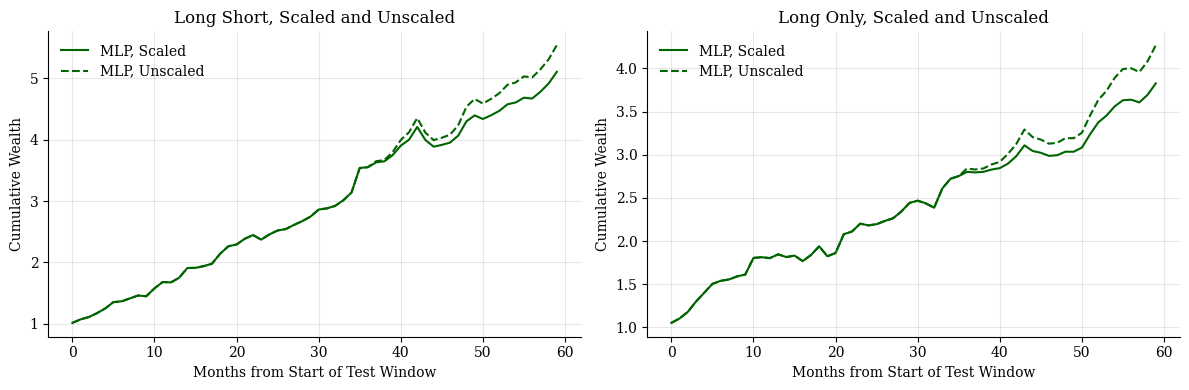

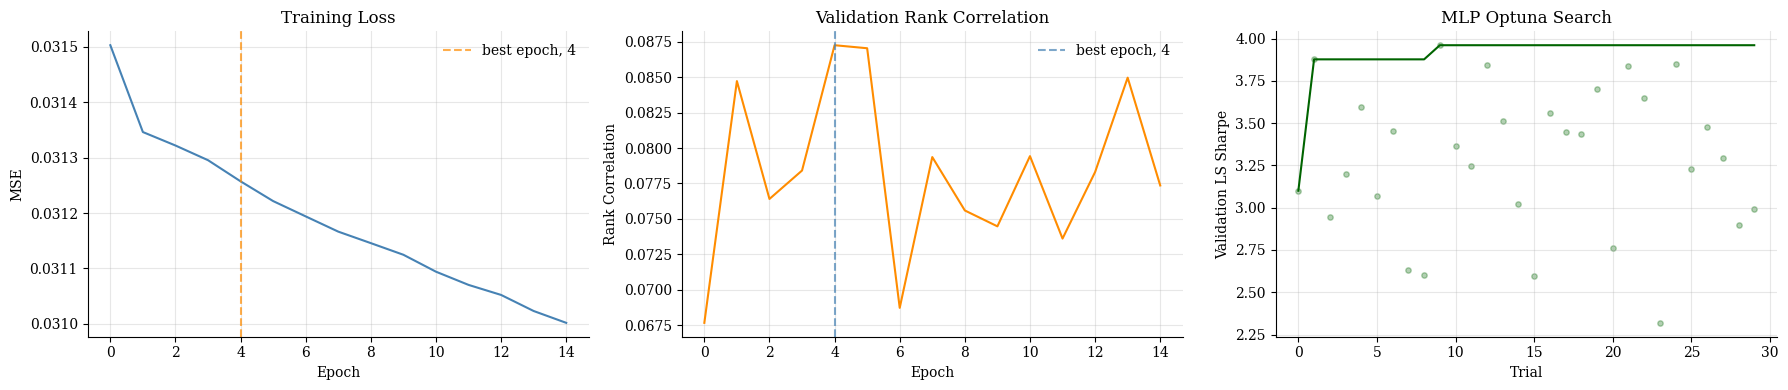

plots saved, em_mlp_cumulative_scaled, em_mlp_cumulative_unscaled, em_mlp_cumulative_combined, em_mlp_diagnostics


In [17]:
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
})

mlp_color = 'darkgreen'


# figure 1, scaled and unscaled overlaid, solid is scaled, dashed is unscaled
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

ax = axes[0]
ax.plot(np.cumprod(1 + ls_scaled), label = 'MLP, Scaled', color = mlp_color)
ax.plot(np.cumprod(1 + ls['returns']), label = 'MLP, Unscaled', color = mlp_color, linestyle = '--')
ax.set_xlabel('Months from Start of Test Window')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Short, Scaled and Unscaled')
ax.legend(frameon = False)
ax.grid(alpha = 0.3)

ax = axes[1]
ax.plot(np.cumprod(1 + lo_scaled), label = 'MLP, Scaled', color = mlp_color)
ax.plot(np.cumprod(1 + lo['returns']), label = 'MLP, Unscaled', color = mlp_color, linestyle = '--')
ax.set_xlabel('Months from Start of Test Window')
ax.set_ylabel('Cumulative Wealth')
ax.set_title('Long Only, Scaled and Unscaled')
ax.legend(frameon = False)
ax.grid(alpha = 0.3)

fig.tight_layout()
fig.savefig(results_dir / 'mlp_cumulative_combined.pdf')
fig.savefig(results_dir / 'mlp_cumulative_combined.png')
plt.show()
plt.close(fig)


# figure 2, training diagnostics, training loss, validation rank correlation, optuna search
fig, axes = plt.subplots(1, 3, figsize = (18, 4))

axes[0].plot(mlp_log['train_losses'], color = 'steelblue')
axes[0].axvline(mlp_log['best_epoch'], color = 'darkorange', linestyle = '--', alpha = 0.7,
                label = f'best epoch, {mlp_log["best_epoch"]}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Training Loss')
axes[0].legend(frameon = False)
axes[0].grid(alpha = 0.3)

axes[1].plot(mlp_log['val_rank_corr'], color = 'darkorange')
axes[1].axvline(mlp_log['best_epoch'], color = 'steelblue', linestyle = '--', alpha = 0.7,
                label = f'best epoch, {mlp_log["best_epoch"]}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Rank Correlation')
axes[1].set_title('Validation Rank Correlation')
axes[1].legend(frameon = False)
axes[1].grid(alpha = 0.3)

mlp_vals = [t.value for t in mlp_study.trials if t.value is not None]
axes[2].plot(np.maximum.accumulate(mlp_vals), color = mlp_color)
axes[2].scatter(range(len(mlp_vals)), mlp_vals, alpha = 0.3, s = 15, color = mlp_color)
axes[2].set_xlabel('Trial')
axes[2].set_ylabel('Validation LS Sharpe')
axes[2].set_title('MLP Optuna Search')
axes[2].grid(alpha = 0.3)

fig.tight_layout()
fig.savefig(results_dir / 'mlp_diagnostics.pdf')
fig.savefig(results_dir / 'mlp_diagnostics.png')
plt.show()
plt.close(fig)

print('plots saved, em_mlp_cumulative_scaled, em_mlp_cumulative_unscaled, em_mlp_cumulative_combined, em_mlp_diagnostics')
